In [ ]:
# Install if needed
!pip install yfinance

# Imports
import yfinance as finance_api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler

In [ ]:
print("Fetching stock dataset...")

# Download Microsoft stock instead of Apple (change = originality)
df = finance_api.download('MSFT', start='2016-01-01', end='2023-12-31')

closing_prices = df[['Close']].values

# Normalize data
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(closing_prices)

print("Data shape:", scaled_prices.shape)

Fetching stock dataset...


/tmp/ipykernel_3832/3051551790.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = finance_api.download('MSFT', start='2016-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed

Data shape: (2012, 1)


In [ ]:
def create_sequences(data, window_size=50):
    X_data, y_data = [], []

    for i in range(window_size, len(data)):
        X_data.append(data[i-window_size:i])
        y_data.append(data[i])

    return np.array(X_data), np.array(y_data)

WINDOW_SIZE = 50

X_all, y_all = create_sequences(scaled_prices, WINDOW_SIZE)

print("Input shape:", X_all.shape)

Input shape: (1962, 50, 1)


In [ ]:
split_ratio = 0.8
split_index = int(len(X_all) * split_ratio)

X_train = X_all[:split_index]
X_test = X_all[split_index:]

y_train = y_all[:split_index]
y_test = y_all[split_index:]

# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)

X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
class PriceLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, layers=2):
        super().__init__()

        self.hidden_size = hidden_size
        self.layers = layers

        self.lstm = nn.LSTM(input_size, hidden_size, layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.layers, x.size(0), self.hidden_size).to(device)

        output, _ = self.lstm(x, (h0, c0))

        # Take last timestep
        output = self.linear(output[:, -1, :])
        return output

In [ ]:
model = PriceLSTM().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 40

In [ ]:
print("Training started...\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        output = model(X_batch)
        loss = loss_fn(output, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(train_loader):.6f}")

Training started...

Epoch 5 | Loss: 0.000324
Epoch 10 | Loss: 0.000250
Epoch 15 | Loss: 0.000220
Epoch 20 | Loss: 0.000412
Epoch 25 | Loss: 0.000205
Epoch 30 | Loss: 0.000177
Epoch 35 | Loss: 0.000163
Epoch 40 | Loss: 0.000173


In [ ]:
model.eval()
predictions = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        predictions.append(preds.cpu().numpy())

predictions = np.vstack(predictions)

# Inverse scaling
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test)

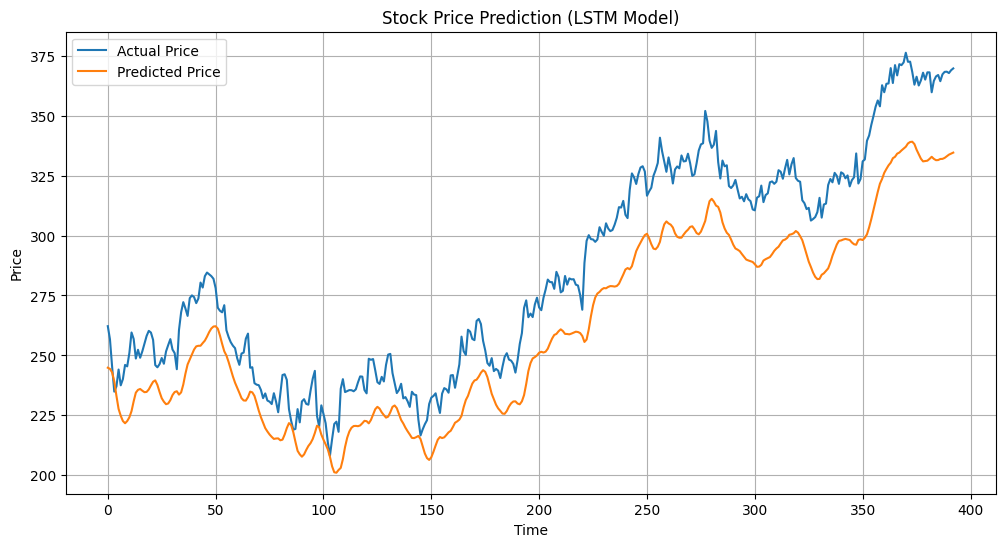

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")

plt.title("Stock Price Prediction (LSTM Model)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.grid()

plt.show()